# Spike Sorting Workflow

Comprehensive walkthrough of the **sorting** submodule: waveform clustering, cluster quality metrics, and diagnostic visualisations.

## 1. Setup & Synthetic Data

We generate two-cluster spike trains via a Poisson process at 25 kHz (0.04 ms bins).
Cluster 1 fires at a flat 5 Hz (orientation-indifferent); cluster 2 peaks at 10 Hz
with Gaussian tuning (σ = 15°, preferred 90°). Both share a 0.5 Hz spontaneous baseline.

In [1]:
%matplotlib inline
from pprint import pprint
import numpy as np
import matplotlib.pyplot as plt
from neural_cca import load_from_arrays, steps2degree

print("Imports successful")

Imports successful


In [ ]:
# ---------------------------------------------------------------------------
# Synthetic two-unit dataset.
#
# ``make_two_unit_demo`` builds the canonical demo used across every
# example notebook: one orientation-indifferent cluster + one
# orientation-selective cluster, with bin-wise inhomogeneous Poisson
# spike trains (1 ms absolute refractory) and Gaussian-template
# waveform snippets, all packaged into a ``SortingData`` container.
# The same helper backs ``tests/conftest.py``\'s spike fixtures, so
# example and test data live in lockstep.
# ---------------------------------------------------------------------------
from neural_cca.synthetic import make_two_unit_demo

demo = make_two_unit_demo(seed=42)

# Expose the legacy variable names downstream cells still reference.
spike_times_c1, trials_c1 = demo.spike_times_c1, demo.trials_c1
spike_times_c2, trials_c2 = demo.spike_times_c2, demo.trials_c2
spike_times = demo.spike_times
trials = demo.trials
waveforms = demo.waveforms
ground_truth = demo.ground_truth
angles = demo.angles
n_trials = demo.n_trials
c2_pref_ori = demo.c2_pref_ori
c2_sigma = demo.c2_sigma
rng = demo.rng

print(f"Cluster 1 (indifferent): {len(spike_times_c1)} spikes")
print(f"Cluster 2 (selective):   {len(spike_times_c2)} spikes")

In [ ]:
# ``make_two_unit_demo`` already merged + chronologically sorted the
# two clusters and packaged them as a ``SortingData`` container; we
# just hand it to the rest of the pipeline.
data = demo.sorting_data
print(f"Merged: {len(spike_times)} spikes | SortingData loaded")

In [4]:
# Inspect available fields in SortingData class
data.__dataclass_fields__.keys()

dict_keys(['waveforms', 'spike_times', 'trials', 'angles', 'waveform_fs', 'n_trials', 'stim_window', 'stim_frequency', 'metadata'])

## 2. Waveform Inspection

Visual inspection of waveform shapes is the first quality check before any automated
sorting. Distinct templates with consistent morphology indicate well-isolated units,
while noisy or overlapping shapes warn of poor signal quality or multi-unit activity.

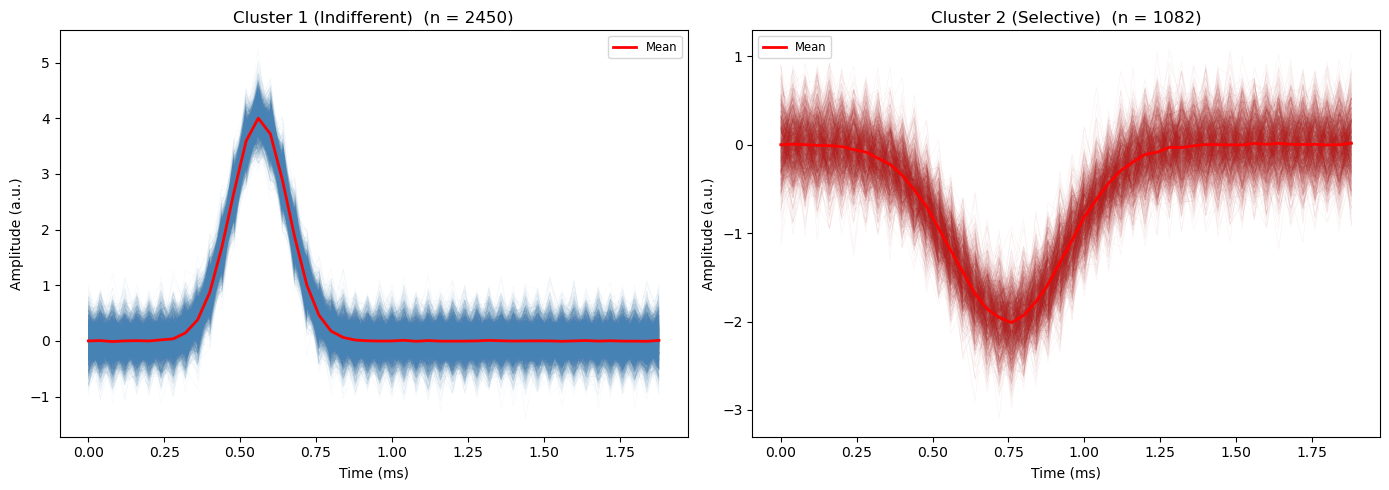

In [5]:
from neural_cca import plot_waveform_snippets

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (mask, title, col) in enumerate(
    [
        (ground_truth == 0, "Cluster 1 (Indifferent)", "steelblue"),
        (ground_truth == 1, "Cluster 2 (Selective)", "firebrick"),
    ]
):
    plot_waveform_snippets(
        waveforms[mask], waveform_fs=25000.0, invert=True, ax=axes[i], color=col, alpha=0.05
    )
    axes[i].set_title(f"{title}  (n = {mask.sum()})")
plt.tight_layout()
plt.show()
plt.close("all")

## 3. PCA Projection

PCA reveals whether clusters are separable in reduced feature space. If two point
clouds are well separated in the first two principal components, KMeans will
cleanly assign labels. Overlapping clouds predict classification errors.

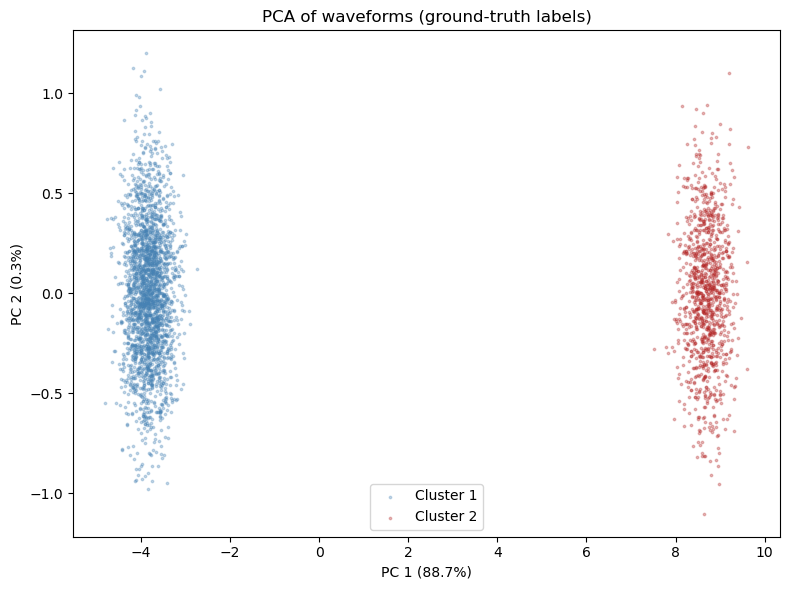

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(waveforms)

fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in [(0, "steelblue", "Cluster 1"), (1, "firebrick", "Cluster 2")]:
    mask = ground_truth == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=3, alpha=0.3, color=color, label=name)
ax.set_xlabel(f"PC 1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC 2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("PCA of waveforms (ground-truth labels)")
ax.legend()
plt.tight_layout()
plt.show()
plt.close("all")

## 4. K-Search: Finding Optimal Clusters

Choosing the right number of clusters is critical — too few merge distinct neurons,
too many split a single neuron's spikes. The silhouette score measures how similar
each spike is to its own cluster versus the nearest other cluster; the k with the
highest mean silhouette is selected.

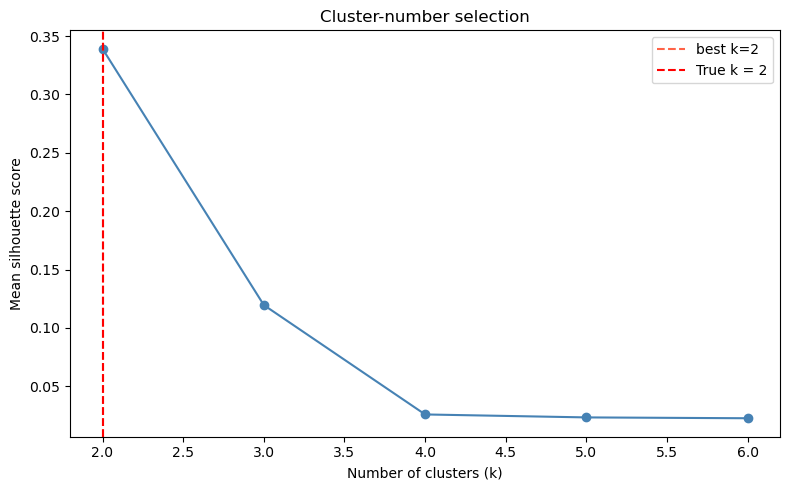

Best k = 2
Silhouette scores: {2: 0.3391365344952404, 3: 0.11956648793825901, 4: 0.025846566428364436, 5: 0.023313015663221814, 6: 0.022591818768009406}


In [7]:
from neural_cca import find_optimal_k, plot_k_search

# Z-score → PCA → KMeans is the recommended feature pipeline.
# Plain raw waveforms (`preprocess="none"`) is the fallback for debugging.
best_k, scores = find_optimal_k(
    waveforms,
    k_range=range(2, 7),
    preprocess="zscore_pca",
    pca_components=0.95,
)

fig, ax = plt.subplots(figsize=(8, 5))
plot_k_search(scores, ax=ax)
ax.axvline(x=2, color="red", ls="--", lw=1.5, label="True k = 2")
ax.legend()
plt.tight_layout()
plt.show()
plt.close("all")

print(f"Best k = {best_k}")
print(f"Silhouette scores: {scores}")

## 5. Spike Sorting (KMeans)

With the optimal k determined, KMeans assigns each spike to a putative neuron by
iteratively minimising within-cluster variance in waveform space. The resulting
labels are the foundation for all downstream per-neuron analyses.

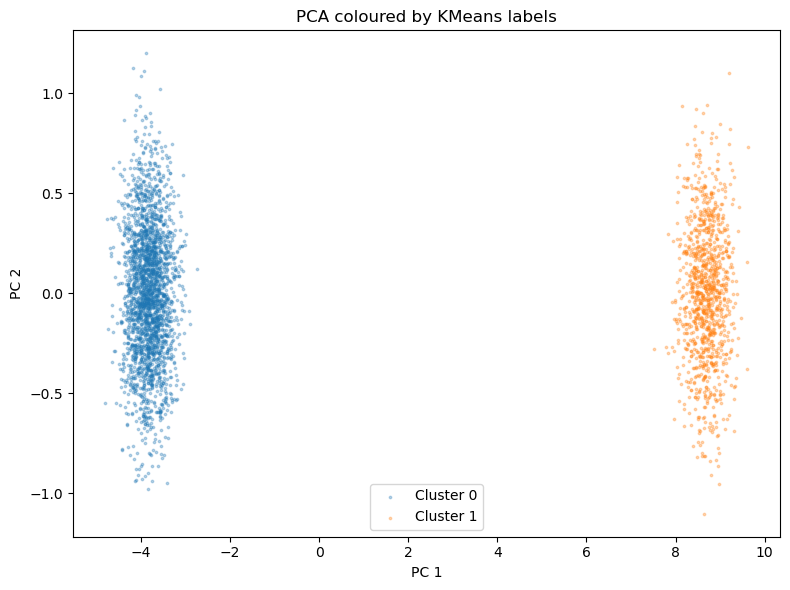

In [8]:
from neural_cca import sort_spikes

# Use the same preprocessing as find_optimal_k above so the
# silhouette score reported earlier corresponds to the actual
# clustering space.
labels, kmeans_model = sort_spikes(
    waveforms,
    n_clusters=best_k,
    preprocess="zscore_pca",
    pca_components=0.95,
)

fig, ax = plt.subplots(figsize=(8, 6))
for cl in range(best_k):
    mask = labels == cl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=3, alpha=0.3, label=f"Cluster {cl}")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_title("PCA coloured by KMeans labels")
ax.legend()
plt.tight_layout()
plt.show()
plt.close("all")

## 6. Sorting Accuracy (Ground-Truth Comparison)

With synthetic data we can quantify how well sorting recovered the true clusters.
Because KMeans labels are arbitrary (cluster 0 might map to either ground-truth
neuron), we try both label mappings and pick the one that maximises accuracy.

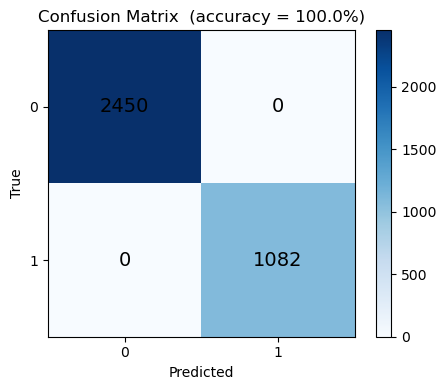

In [9]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Try both label mappings
acc_direct = accuracy_score(ground_truth, labels)
acc_flipped = accuracy_score(ground_truth, 1 - labels)
best_acc = max(acc_direct, acc_flipped)
mapped_labels = labels if acc_direct >= acc_flipped else 1 - labels

cm = confusion_matrix(ground_truth, mapped_labels)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=14)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix  (accuracy = {best_acc:.1%})")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
plt.close("all")

## 7. Silhouette Analysis

The silhouette coefficient for each spike ranges from −1 (badly misassigned) to +1
(well within its own cluster). The fraction of negative-silhouette spikes is a
compact quality indicator: 0 % means every spike sits closer to its own cluster
centroid than to any other.

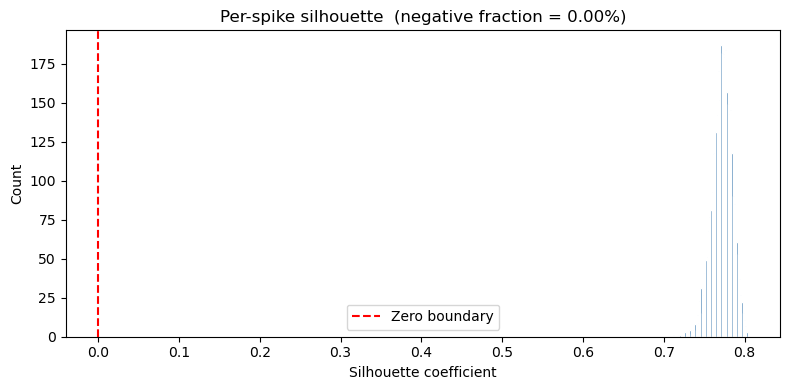

In [10]:
from sklearn.metrics import silhouette_samples
from neural_cca.sorting.metrics import neg_silhouette_score

sil_vals = silhouette_samples(waveforms, labels)
neg_rel = neg_silhouette_score(waveforms, labels, relative=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sil_vals, bins=60, color="steelblue", edgecolor="white")
ax.axvline(0, color="red", ls="--", label="Zero boundary")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Count")
ax.set_title(f"Per-spike silhouette  (negative fraction = {neg_rel:.2%})")
ax.legend()
plt.tight_layout()
plt.show()
plt.close("all")

## 8. Refractory Period Violations (RPVs)

Biological neurons cannot fire within ~1 ms of a previous spike. ISI violations
shorter than the refractory period suggest the cluster contains spikes from more
than one neuron, or is contaminated by noise.

In [11]:
from neural_cca.sorting.metrics import rpvs

rpv_abs = rpvs(spike_times, labels, refractory_period=0.001, relative=False, all_clusters=True)
rpv_rel = rpvs(spike_times, labels, refractory_period=0.001, relative=True, all_clusters=True)
print(f"Absolute RPVs: {rpv_abs}")
print(f"Relative RPVs: {rpv_rel:.4f}")

for cl in range(best_k):
    r = rpvs(
        spike_times,
        labels,
        refractory_period=0.001,
        relative=True,
        all_clusters=False,
        cluster_id=cl,
    )
    print(f"  Cluster {cl}: {r:.4f}")

Absolute RPVs: 2006
Relative RPVs: 0.5680
  Cluster 0: 0.6522
  Cluster 1: 0.3771


## 9. Signal-to-Noise Ratio

SNR determines whether waveform features are reliable enough for clustering. It is
computed as (peak-to-peak of mean waveform) / (2 × std of residuals). Higher SNR
means more distinctive waveforms, leading to better cluster separation.

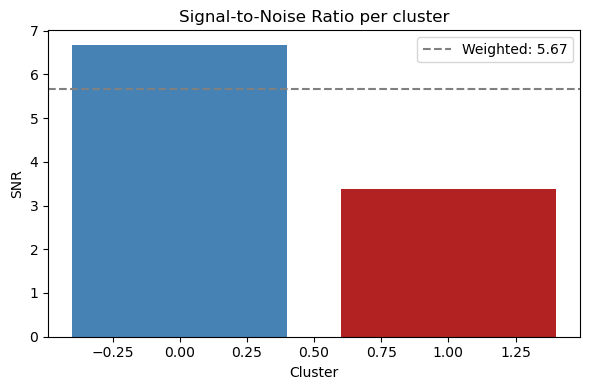

In [12]:
from neural_cca.sorting.metrics import est_snr, calc_weighted_snr

snr_per_cluster = {}
for cl in range(best_k):
    snr_per_cluster[cl] = est_snr(waveforms[labels == cl])
weighted_snr = calc_weighted_snr(waveforms, labels)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(snr_per_cluster.keys(), snr_per_cluster.values(), color=["steelblue", "firebrick"])
ax.axhline(weighted_snr, color="gray", ls="--", label=f"Weighted: {weighted_snr:.2f}")
ax.set_xlabel("Cluster")
ax.set_ylabel("SNR")
ax.set_title("Signal-to-Noise Ratio per cluster")
ax.legend()
plt.tight_layout()
plt.show()
plt.close("all")

## 10. Isolation Distance & L-Ratio

These Mahalanobis-based metrics quantify cluster separation in feature space
(Harris et al. 2001). Isolation distance is the squared Mahalanobis distance
enclosing as many non-cluster spikes as cluster spikes — larger is better.
L-ratio normalises the summed chi-squared tail probabilities of non-cluster
spikes — smaller (< 0.1) is better.

In [13]:
from neural_cca import isolation_distance, l_ratio

iso = isolation_distance(waveforms, labels, all_clusters=False, cluster_id=0)
lr = l_ratio(waveforms, labels, all_clusters=False, cluster_id=0)
print(f"Cluster 0 — Isolation distance: {iso:.1f}  |  L-ratio: {lr:.4f}")

iso1 = isolation_distance(waveforms, labels, all_clusters=False, cluster_id=1)
lr1 = l_ratio(waveforms, labels, all_clusters=False, cluster_id=1)
print(f"Cluster 1 — Isolation distance: {iso1}  |  L-ratio: {lr1:.4f}")

Cluster 0 — Isolation distance: nan  |  L-ratio: 0.0000
Cluster 1 — Isolation distance: 1776.9438049609794  |  L-ratio: 0.0000


## 11. d-Prime & Cluster Separability

d-prime from signal detection theory measures how discriminable two clusters are
in feature space. A d-prime > 2 indicates good separation. The d-prime matrix
visualises all pairwise comparisons.

d-prime: {0: 41.68921302981784, 1: 41.68921302981784}


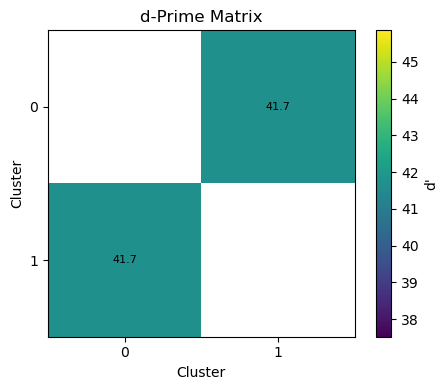

In [14]:
from neural_cca import d_prime, plot_d_prime_matrix

dp = d_prime(waveforms, labels, all_clusters=True)
print(f"d-prime: {dp}")

fig, ax = plt.subplots(figsize=(5, 4))
plot_d_prime_matrix(waveforms, labels, ax=ax)
ax.set_title("d-Prime Matrix")
plt.tight_layout()
plt.show()
plt.close("all")

## 12. Peak Amplitude SNR

Peak amplitude SNR is shape-independent: it measures the maximum waveform
deflection relative to baseline noise. This directly reflects how detectable the
spike is above the noise floor of the recording.

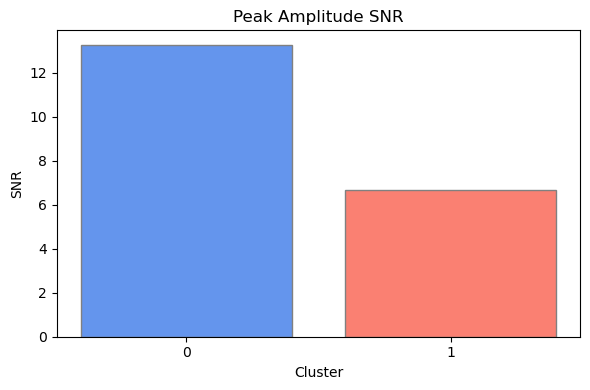

In [15]:
from neural_cca import peak_amplitude_snr, plot_metric_bars

pa_snr = peak_amplitude_snr(waveforms, labels, all_clusters=False, cluster_id=0)
pa_snr1 = peak_amplitude_snr(waveforms, labels, all_clusters=False, cluster_id=1)
metric_dict = {0: pa_snr, 1: pa_snr1}

fig, ax = plt.subplots(figsize=(6, 4))
plot_metric_bars(metric_dict, title="Peak Amplitude SNR", ylabel="SNR", ax=ax)
plt.tight_layout()
plt.show()
plt.close("all")

## 13. Waveform Stability

Stable waveforms across the recording indicate the electrode maintained consistent
contact with the neuron. This is assessed by correlating the mean waveform from the
first quarter of spikes with the last quarter — a correlation near 1.0 is ideal.

Cluster 0: waveform stability = 0.9998
Cluster 1: waveform stability = 0.9992


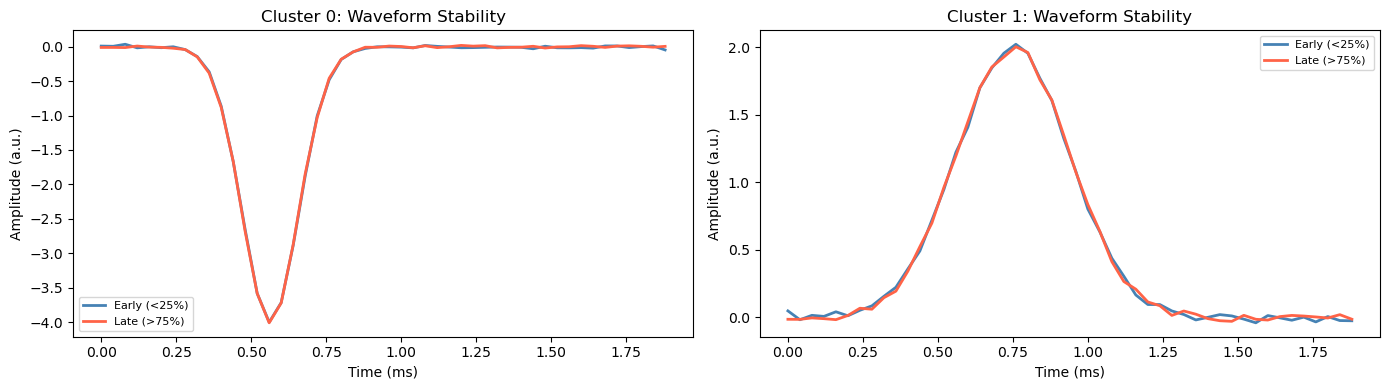

In [16]:
from neural_cca import waveform_stability, plot_waveform_stability

for cl in range(best_k):
    ws = waveform_stability(spike_times, waveforms, labels, all_clusters=False, cluster_id=cl)
    print(f"Cluster {cl}: waveform stability = {ws:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for cl, ax in enumerate(axes):
    plot_waveform_stability(
        spike_times, waveforms, cluster_labels=labels, cluster_id=cl, waveform_fs=25000.0, ax=ax
    )
    ax.set_title(f"Cluster {cl}: Waveform Stability")
plt.tight_layout()
plt.show()
plt.close("all")

## 14. Amplitude Drift

Systematic amplitude drift — a trend of increasing or decreasing peak amplitude
over the session — can indicate electrode movement or tissue changes. It is
measured as the Spearman correlation of peak amplitude vs. spike index.

Cluster 0: amplitude drift (Spearman r) = -0.0112
Cluster 1: amplitude drift (Spearman r) = -0.0410


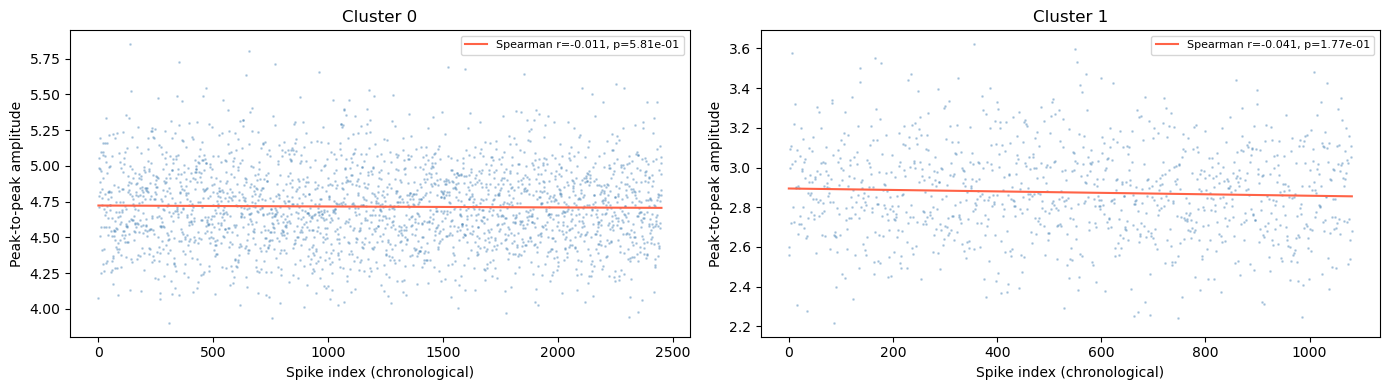

In [17]:
from neural_cca import amplitude_drift, plot_amplitude_drift

for cl in range(best_k):
    ad = amplitude_drift(waveforms, labels, all_clusters=False, cluster_id=cl)
    print(f"Cluster {cl}: amplitude drift (Spearman r) = {ad:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for cl, ax in enumerate(axes):
    plot_amplitude_drift(waveforms, cluster_labels=labels, cluster_id=cl, ax=ax)
    ax.set_title(f"Cluster {cl}")
plt.tight_layout()
plt.show()
plt.close("all")

## 15. Fraction Missing

If the amplitude distribution is clipped on one side, some spikes fell below the
detection threshold. The fraction missing estimates how many spikes were lost by
fitting a Gaussian to the amplitude histogram and integrating the unobserved tail.

Cluster 0: fraction missing = 0.0023
Cluster 1: fraction missing = 0.0027


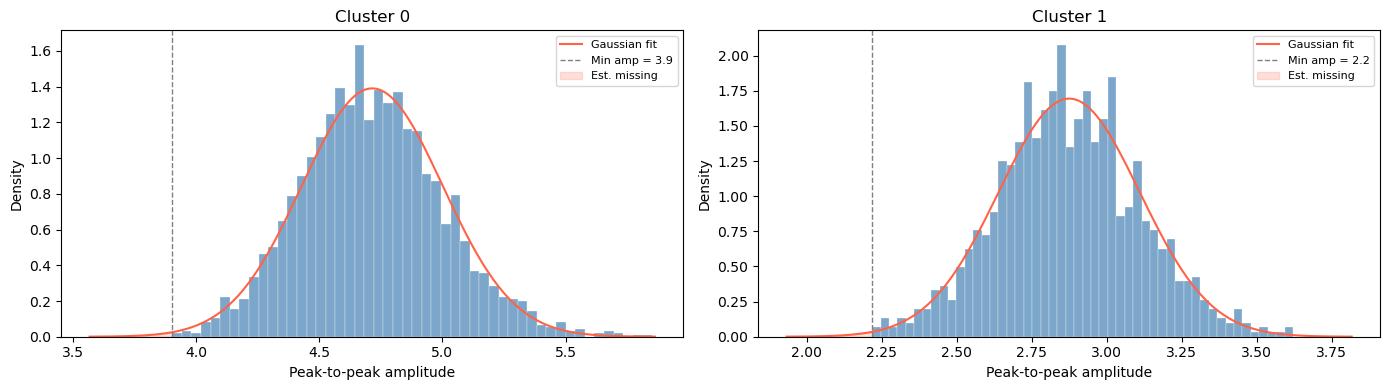

In [18]:
from neural_cca import fraction_missing, plot_amplitude_histogram

for cl in range(best_k):
    fm = fraction_missing(waveforms, labels, all_clusters=False, cluster_id=cl)
    print(f"Cluster {cl}: fraction missing = {fm:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for cl, ax in enumerate(axes):
    plot_amplitude_histogram(waveforms, cluster_labels=labels, cluster_id=cl, ax=ax)
    ax.set_title(f"Cluster {cl}")
plt.tight_layout()
plt.show()
plt.close("all")

## 16. Full Sorting Pipeline

`run_sorting_pipeline` automates all steps above: k-selection, clustering, quality
evaluation, and diagnostic figure production in a single call.

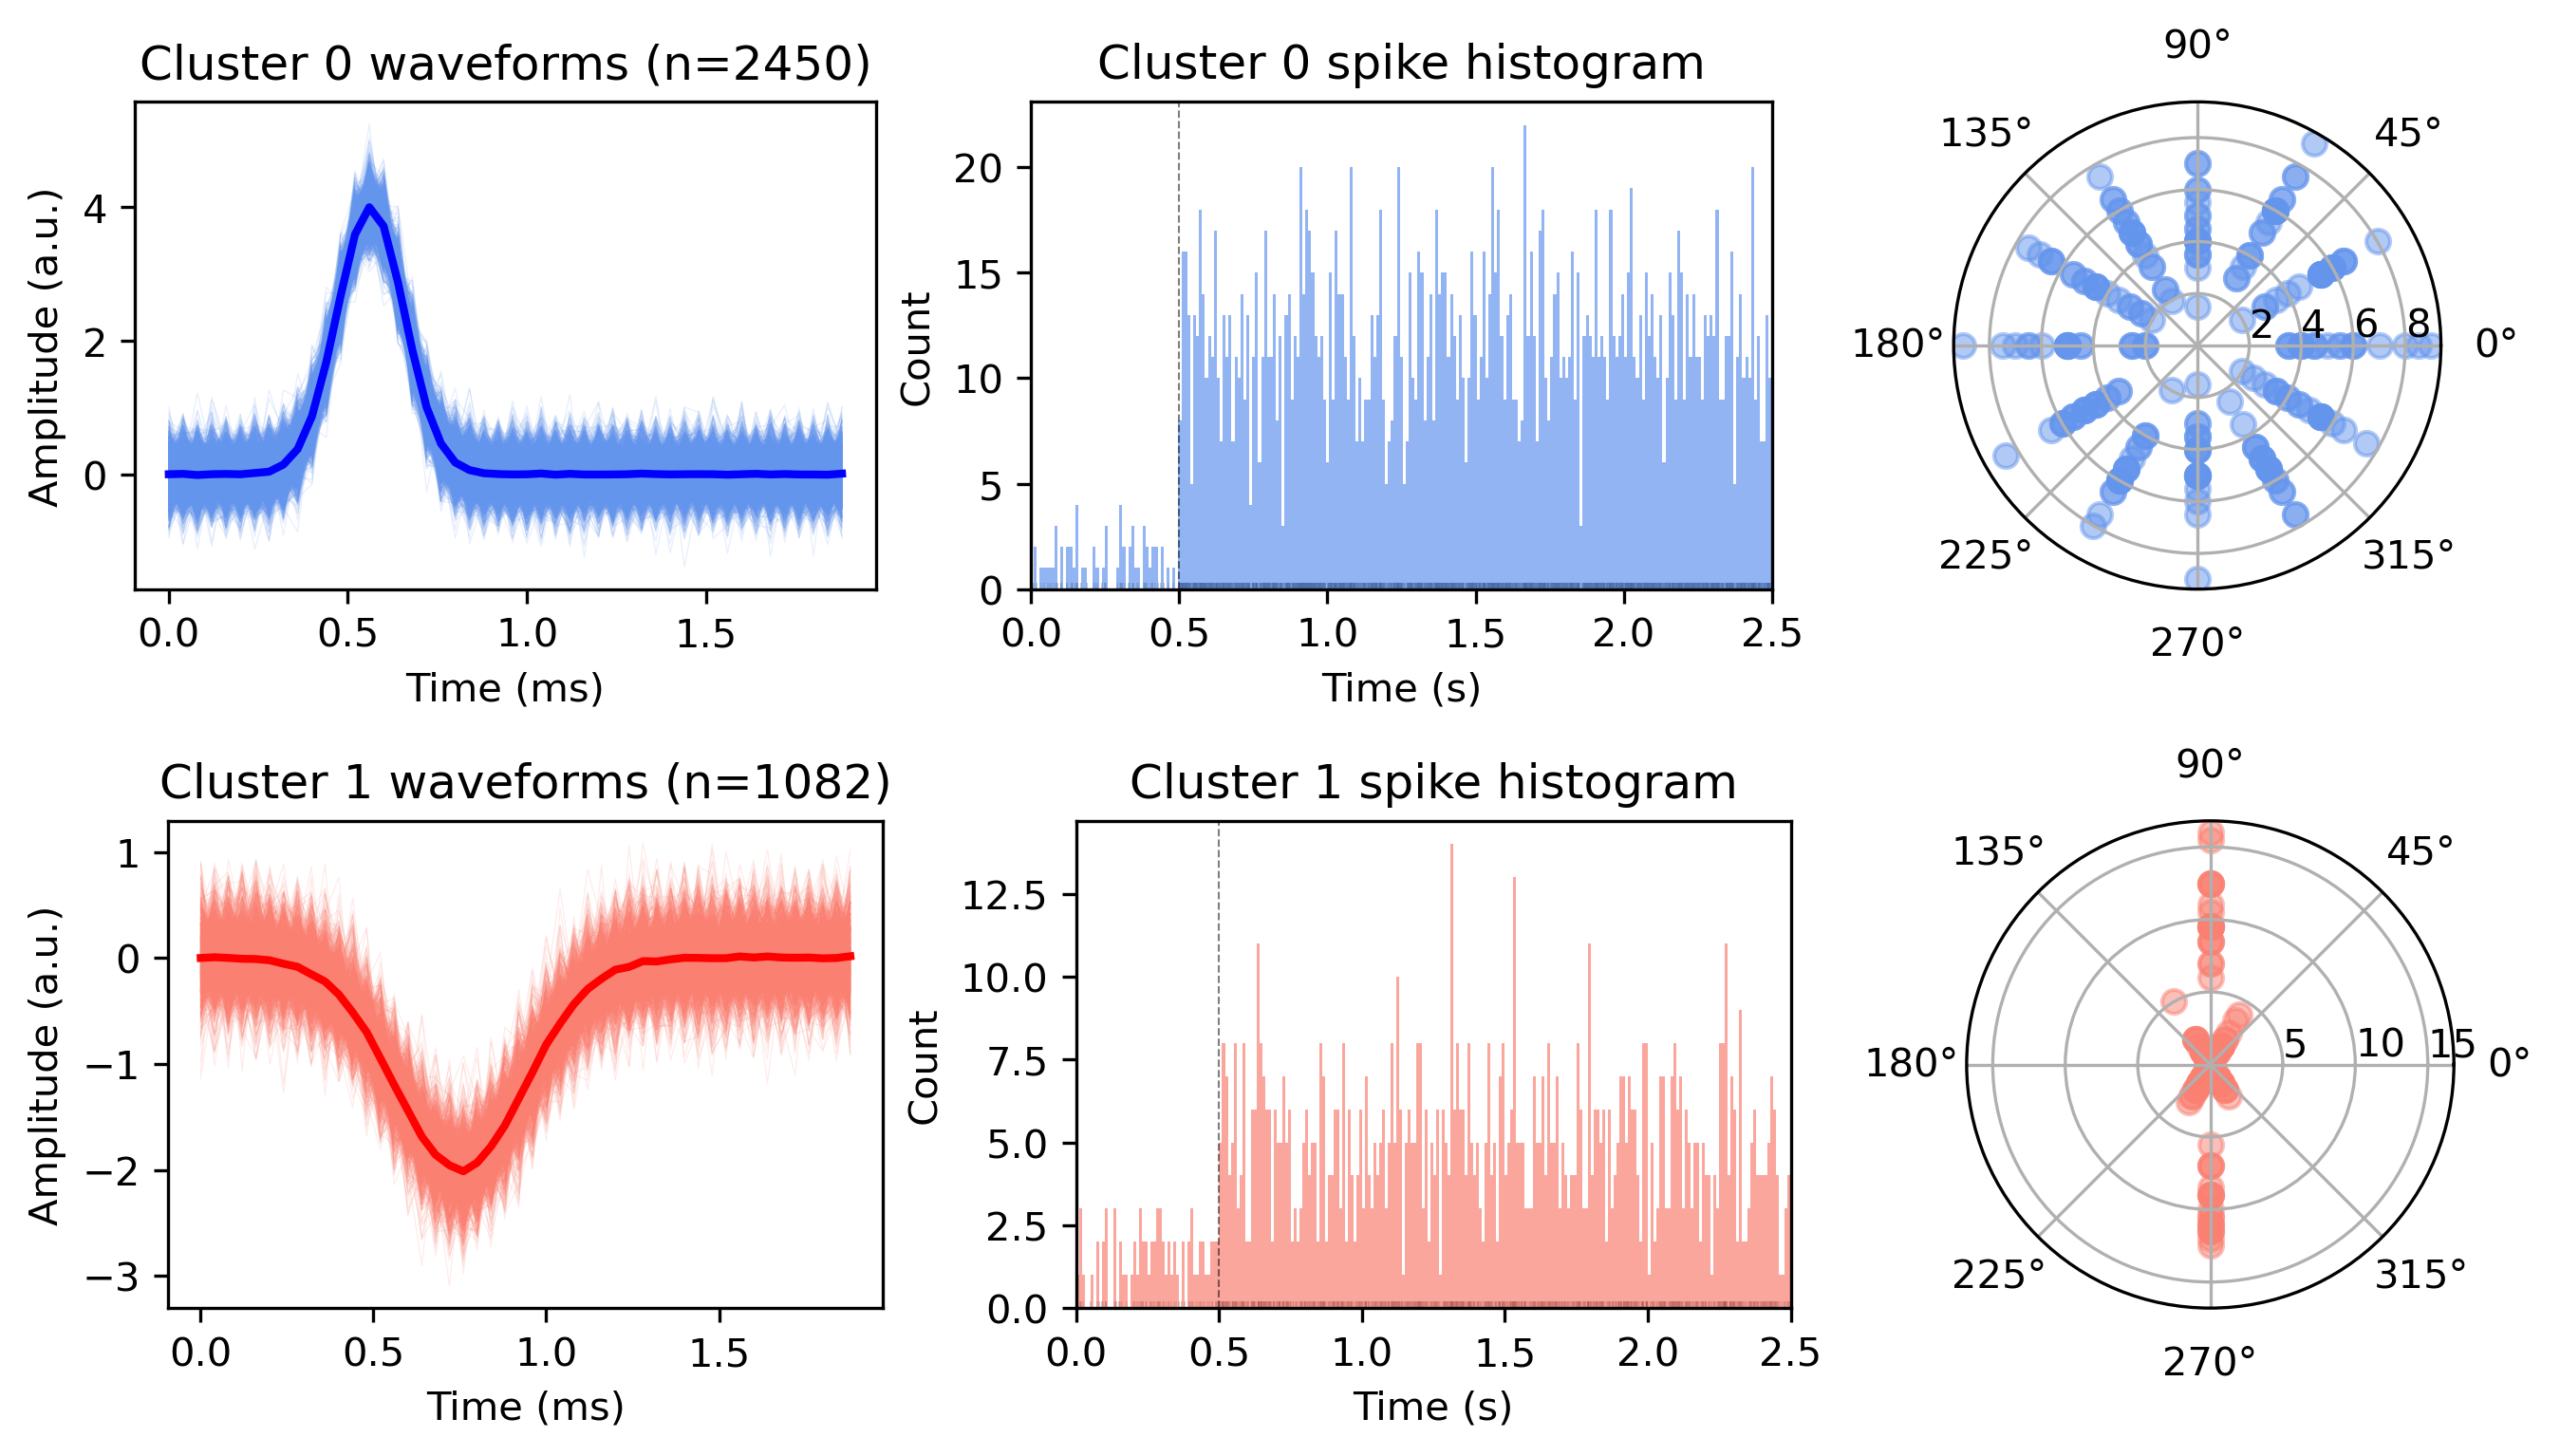

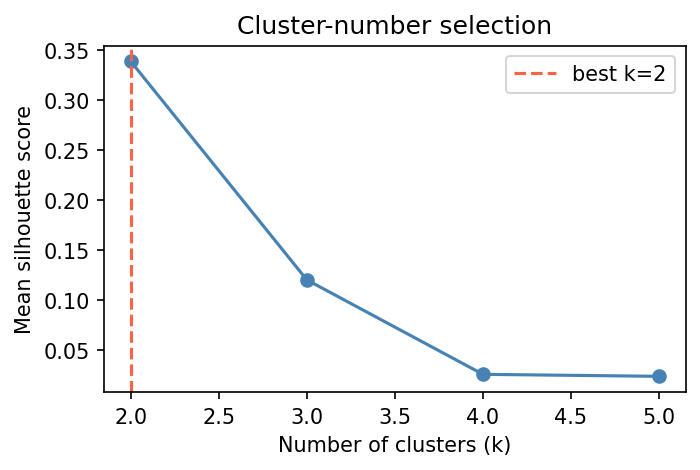

Clusters: 2
Preprocessing: zscore_pca (pca_components=0.95)

K-search: {2: 0.3391365344952404, 3: 0.12031387404930009, 4: 0.025770000508151224, 5: 0.023770828704989713}


In [19]:
from neural_cca import run_sorting_pipeline

# `preprocess` and `pca_components` are explicit parameters of the
# pipeline; they are recorded in `result.metadata` so the methods
# section can cite the exact feature pipeline that was used.
result_full = run_sorting_pipeline(
    data,
    preprocess="zscore_pca",
    pca_components=0.95,
    plot=True,
)
plt.close("all")

print(f"Clusters: {result_full.n_clusters}")
print(
    f"Preprocessing: {result_full.metadata['preprocess']} "
    f"(pca_components={result_full.metadata['pca_components']})"
)
print(f"\nK-search: {result_full.k_search}")

In [20]:
# Inspect SortingResult fields
result_full.__dataclass_fields__.keys()

dict_keys(['cluster_labels', 'n_clusters', 'quality', 'os_metrics', 'k_search', 'metadata'])

## 17. Comprehensive Quality Report

`evaluate_sorting` returns all quality metrics in one dictionary. This is the
recommended way to generate a per-session quality report.

In [21]:
from neural_cca import evaluate_sorting

quality = evaluate_sorting(data, labels)
print("Full quality report:")
pprint(quality)

Full quality report:
{'abs_rpvs': 2006,
 'amplitude_drift': {0: -0.011150303245636971, 1: -0.04102941155643329},
 'd_prime': {0: 41.68921302981784, 1: 41.68921302981784},
 'fraction_missing': {0: 0.0023172274855212623, 1: 0.0026539807031766274},
 'isolation_distance': {0: nan, 1: 1776.9438049609794},
 'l_ratio': {0: 0.0, 1: 0.0},
 'neg_silhouette_rel': 0.0,
 'peak_amplitude_snr': {0: 13.269471364695587, 1: 6.680435936772619},
 'rel_rpvs': 0.5679501698754247,
 'silhouette_mean': 0.7720597348984913,
 'snr_per_cluster': {0: 6.673557250708165, 1: 3.3815522763866652},
 'snr_weighted': 5.665077810669699,
 'waveform_stability': {0: 0.9998282535021521, 1: 0.999175260352668}}


## Summary

| Metric | What it tells you | Ideal value |
|---|---|---|
| Silhouette | Cluster cohesion vs. separation | > 0.5 |
| RPV rate | Sorting purity (refractory violations) | < 1 % |
| SNR | Waveform detectability | > 4 |
| Isolation distance | Mahalanobis separation | > 20 |
| L-ratio | Contamination from neighbours | < 0.1 |
| d-prime | Signal-detection separability | > 2 |
| Peak amplitude SNR | Detectability above noise floor | > 5 |
| Waveform stability | Electrode consistency | > 0.95 |
| Amplitude drift | Electrode movement | |r| < 0.1 |
| Fraction missing | Missed spikes | < 5 % |

All metrics computed here serve a single goal: ensuring that the spikes assigned
to each cluster truly originate from one neuron and one neuron only.

## 18. Export Results to Zarr

The sorting result and input data can be persisted as a zarr store for efficient
downstream access. Two layouts are available:

- **Flat** — arrays keep their original `(n_spikes, ...)` shape.
- **Clustered** — per-spike arrays are reshaped to `(n_clusters, max_spikes, ...)` with NaN / -1 padding, one cluster per chunk for efficient per-cluster reads.

In [22]:
import tempfile, os, shutil
from neural_cca import to_zarr_flat, to_zarr_clustered, read_zarr_sorting

tmpdir = tempfile.mkdtemp()
flat_store = os.path.join(tmpdir, "sorting_flat.zarr")
clustered_store = os.path.join(tmpdir, "sorting_clustered.zarr")

# --- Flat export -------------------------------------------------------------
root_flat = to_zarr_flat(result_full, data, flat_store)

print("Flat export")
print(f"  labels      : {root_flat['cluster_labels'].shape}")
print(f"  spike_times : {root_flat['spike_times'].shape}")
print(f"  waveforms   : {root_flat['waveforms'].shape}")
print(f"  trials      : {root_flat['trials'].shape}")
print(f"  angles      : {root_flat['angles'].shape}")

# --- Clustered export --------------------------------------------------------
root_cl = to_zarr_clustered(result_full, data, clustered_store)

print(f"\nClustered export")
print(f"  cluster_ids : {root_cl['cluster_ids'].shape}")
print(f"  spike_count : {root_cl['spike_count'].shape}")
print(f"  spike_times : {root_cl['spike_times'].shape}")
print(f"  waveforms   : {root_cl['waveforms'].shape}")
print(f"  trials      : {root_cl['trials'].shape}")
print(f"  angles      : {root_cl['angles'].shape}")

# --- Roundtrip verification --------------------------------------------------
result_rt, data_rt = read_zarr_sorting(flat_store)

print(f"\nRoundtrip verification (flat store)")
print(
    f"  Labels match:      {np.array_equal(result_full.cluster_labels, result_rt.cluster_labels)}"
)
print(f"  Spike times match: {np.allclose(data.spike_times, data_rt.spike_times)}")
print(f"  Waveforms match:   {np.allclose(data.waveforms, data_rt.waveforms)}")
print(f"  n_clusters:        {result_rt.n_clusters}")

Flat export
  labels      : (3532,)
  spike_times : (3532,)
  waveforms   : (3532, 48)
  trials      : (3532,)
  angles      : (240,)

Clustered export
  cluster_ids : (2,)
  spike_count : (2,)
  spike_times : (2, 2450)
  waveforms   : (2, 2450, 48)
  trials      : (2, 2450)
  angles      : (240,)

Roundtrip verification (flat store)
  Labels match:      True
  Spike times match: True
  Waveforms match:   True
  n_clusters:        2


In [23]:
# Clean up
shutil.rmtree(tmpdir)
print(f"\nCleaned up temporary directory.")


Cleaned up temporary directory.
